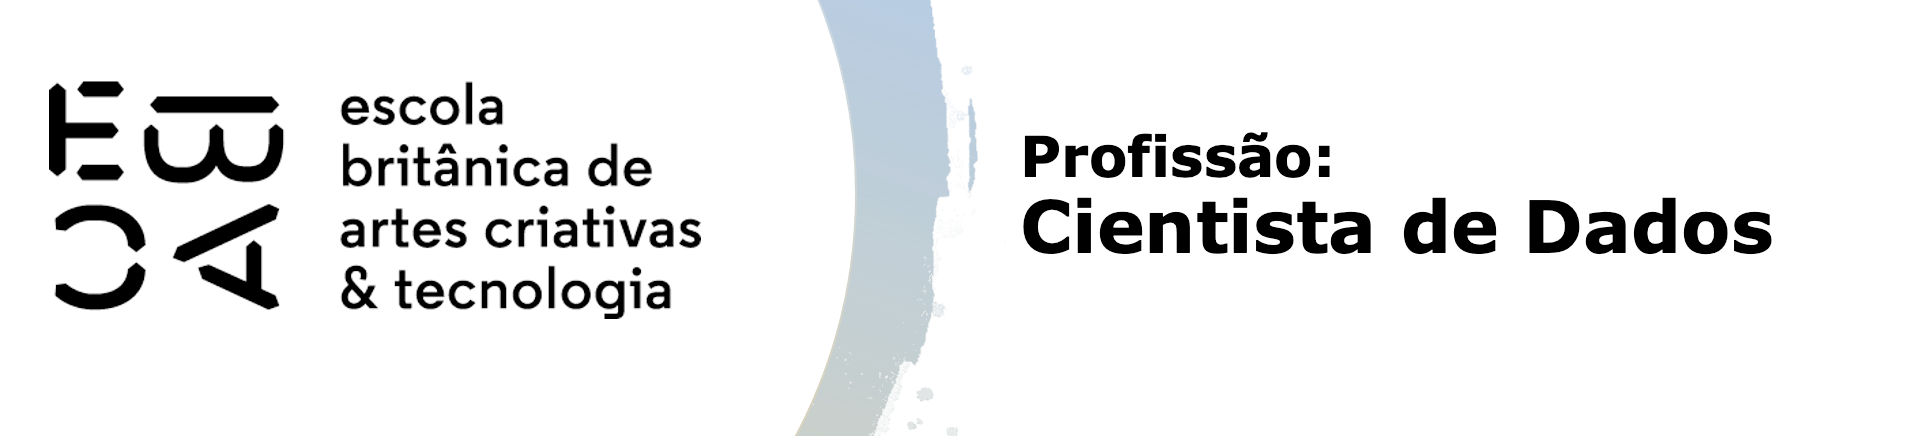

# Task

Load the base ```NFP.ftr```. This database comes from the #AMABiliDados project, and contains data from the São Paulo NF registered for automatic donation to AMA, the Association of Friends of Autistic People.

The *Nota Fiscal Paulista* is an incentive program from the government of the state of São Paulo, which returns a small amount of ICMS to the consumer whenever they request the registration of their CPF on the NF. In this program, the taxpayer can direct their credits to an NGO, and when they do this, whenever this registered consumer makes a purchase, the credits from unidentified banknotes issued by the same establishment (notes without CPF) are "dragged" to the NGO in the form of a donation.

Click on the link if you want to know more about [AMA](https://www.ama.org.br/site/).<br>
Click on the link if you want to know how a citizen can be an [NFP donor](https://doacao1.ama.org.br/sitenfp).

This database has data on the notes whose contributors directed their credits to the AMA. Its fields are described below:

|Field|Description|
|:-|:-|
|CNPJ issued.| CNPJ of the NF issuer |
|Issuer| Trade name of the NF issuer |
|No.| NF number |
|Issuance Date| NF issuance date |
|NF Value| NF value |
|Registration Date| Date of registration in the NFP system |
|Credits| Value of credits (donation) |
|Credit Status| If the credit has already been paid, is being processed, etc.|
|Year| Year of NF issuance |
|Semester| Semester of NF issuance |
|Return| Credit value divided by NF value |
|flag_credit| Indicator if the NF has positive credit |
|category| NF categorization |

**OBJECTIVE:** Some NF do not provide returns, which can occur for a variety of reasons, one of which would be the occurrence of non-incentivized products such as cigarettes and alcoholic beverages. Our goal is to try to predict which type of grade is more or less likely to provide credits.

**Note**: This is a real basis, with characteristics in agreement. There may be a variability that is difficult to explain, partly because of a frequency of notes that is inconsistent over time (for various reasons), partly because there is important information, protected by the LGPD, not included in the base, which can interfere with the credit generated, the which will cause variability that is difficult to explain. *Welcome to the jungle*, Real life is like this :)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle('base_nfp.pkl')
df.head()

,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria
0,03.476.811/0741-98,DIA BRASIL SOCIEDADE LIMITADA,537,2017-06-30,24.68,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Mercado
1,43.101.310/0001-05,AUTO POSTO ZANWAL LTDA EPP,2894,2017-06-30,50.00,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Auto posto
2,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,699,2017-06-30,27.00,2017-06-30,0.44,Liberado,2017,1,0.016296,1,Restaurantes
3,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,698,2017-06-30,111.50,2017-06-30,1.81,Liberado,2017,1,0.016233,1,Restaurantes
4,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,694,2017-06-30,125.00,2017-06-30,2.03,Liberado,2017,1,0.016240,1,Restaurantes


## Analysis of return probability

Only consider data from January 2020 onwards for this analysis.

- Analyze the proportion of NF that returned > 0 by establishment category. This analysis can be done by table or graph.

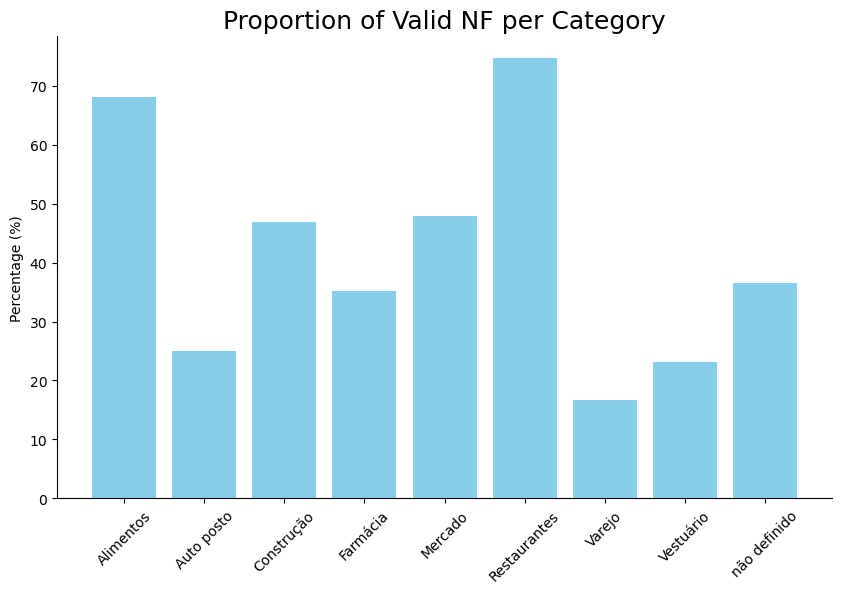

In [2]:
#################### DATA DISCRIMINATE ####################

df_filtered = df[df['Data Emissão'] >= '2020-01-01']
df_valid = df_filtered[df_filtered['Retorno'] > 0]

#################### AGGREGATION BY CATEGORY ####################

total_notes_per_category = df_filtered.groupby('categoria')['Retorno'].count()
valid_notes_per_category = df_valid.groupby('categoria')['Retorno'].count()

proportion_per_category = (100 * valid_notes_per_category / total_notes_per_category).reset_index()
proportion_per_category.columns = ['category', 'proportion']

#################### PLOT OF PROPORTIONS ####################

plt.figure(figsize=(10, 6))
ax = plt.gca()
plt.bar(proportion_per_category['category'], proportion_per_category['proportion'], color='skyblue')
plt.xlabel('')
plt.ylabel('Percentage (%)')
plt.title('Proportion of Valid NF per Category', fontsize= 18)
plt.xticks(rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

## WOE calculation

- Calculate the WOE of the categories, with the event in question being the score having a return > 0.
- Analyze this WOE by table and graph.

In [15]:
#################### CALCULATING THE WOE OF CATEGORIES ####################

crosstab = pd.crosstab(df['categoria'], df['Retorno'] > 0, margins=True, margins_name='Total')
crosstab.columns = ['No', 'Yes', 'Total']

crosstab['pct_no'] = crosstab['No']/crosstab.loc['Total', 'No']
crosstab['pct_yes'] = crosstab['Yes']/crosstab.loc['Total', 'Yes']

crosstab['RC'] = crosstab['pct_yes']/crosstab['pct_no']
crosstab['WOE'] = np.log(crosstab.RC)
crosstab.round(3)

,No,Yes,Total,pct_no,pct_yes,RC,WOE
categoria,,,,,,,
Alimentos,2092,12868,14960,0.020,0.152,7.486,2.013
Auto posto,3418,271,3689,0.033,0.003,0.096,-2.338
Construção,18425,13811,32236,0.179,0.163,0.912,-0.092
Farmácia,10054,4886,14940,0.098,0.058,0.591,-0.525
Mercado,22887,19808,42695,0.222,0.234,1.053,0.052
Restaurantes,22631,17118,39749,0.220,0.202,0.921,-0.083
Varejo,4869,1035,5904,0.047,0.012,0.259,-1.352
Vestuário,1813,1799,3612,0.018,0.021,1.208,0.189
não definido,16819,13042,29861,0.163,0.154,0.944,-0.058


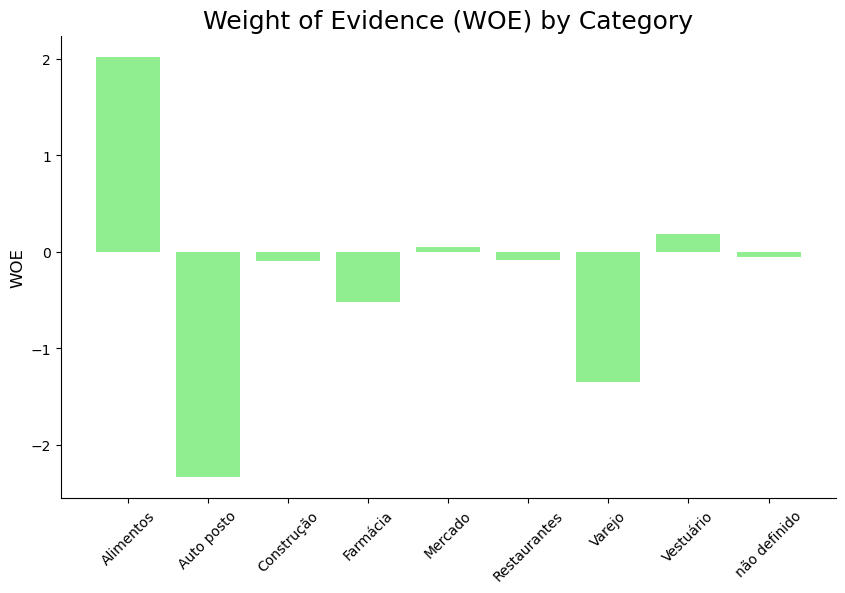

In [11]:
#################### PLOT OF WOE ####################

crosstab = crosstab.drop(index='Total')

plt.figure(figsize=(10, 6))
ax = plt.gca()
plt.bar(crosstab.index, crosstab['WOE'], color='lightgreen')
plt.xlabel('')
plt.ylabel('WOE', fontsize=12)
plt.title('Weight of Evidence (WOE) by Category', fontsize=18)
plt.xticks(rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

## Finding the *Information Value*

Calculate the *IV* of this variable.

In [18]:
crosstab['parcial_IV'] = (crosstab.pct_yes - crosstab.pct_no) * crosstab.WOE
iv = crosstab.parcial_IV.sum() * 100
print(f'Information Value: {iv: .1f} %')

Information Value:  40.8 %


- <font color='blue'>Results of WOE by Category & commentaries:</font>

> **Foods**: 2,013 (positive and high), means “Foods” are much more likely to have a positive return .
> 
> **Auto station**: -2,338 (negative and high), so it has a much lower probability of having a positive return compared to other categories.
> 
> **Construction**: -0.092 (slightly negative), this category has a very small tendency to have revenue.
> 
> **Pharmacy**: -0.525 (negative), the "Pharmacy" category is less likely to have positive returns.
>
> **Market**: 0.052 (slightly positive), this category has a very small tendency to have revenue a little bit over the average.
> 
> **Restaurants**: -0.083 (slightly negative), same as Construction.
>
> **Retail**: -1,352 (negative and high), this category is significantly less likely to have positive returns than others.
>
> **Clothing**: 0.189 (positive), "Clothing" category is more likely to have positive returns.
> 
> **undefined**: -0.058 (slightly negative), this extra category has a small tendency to have fewer positive returns, despite of its finnancial implications.
>
- <font color='blue'>Information Value (IV) interpretation:</font>

> **IV**: 40,8% (on range of 30% to 50%), this suggests that the categories provide a reasonable discrimination between NFs with and without positive returns.

- <font color='red'><b>Conclusion</b>:</font>

> **Strong Categories**: “Food” and “Clothing” are categories that significantly increase the chance of a positive return, numerically and visually speaking.
<br>
> **Weak Categories**: "Auto station" and "Retail" have less chance of a positive return, as the mathematical and graphical analysis presents.
<br>
> **Predictive Strength**: WOE & IV analysis indicates that the "category" variable has a moderate predictive strength for return.